# 4. A real Platynereis nucleus-texture MAE, slowly and end to end

This notebook deliberately pauses after every consequential transformation. We will first
inspect one real patch and its identity, then quantify the cohort, then train. Every plot has an
interpretation question next to it; completing a cell is not treated as biological evidence.

**What one row means:** one exported row represents the cell-associated nucleus belonging to
`label_id`. It summarizes several local, nucleus-masked EM texture patches. It is therefore a
**nucleus-derived texture embedding**, not a whole-cell embedding and not the historical
six-group, 480-dimensional MorphoFeatures representation.

The large N5 stores remain read-only and external. Resolved YAML, split manifests, metrics,
checkpoints, embeddings, figures, and provenance are written below the configured output root.
The quick profile is an executable pipeline check; the full profile is a realistic starting
budget whose scientific usefulness still has to be demonstrated.

## 1 — Choose one YAML and make notebook changes explicit

The YAML model is canonical. `NOTEBOOK_OVERRIDES` is intentionally small and deep-merged into
the selected profile; the resolved result is validated and saved. This prevents the common
failure mode in which a notebook silently uses settings that never reach the cluster job.

- site `quick`: 1,000 biological IDs, 64 complete texture-patch tokens per nucleus, 50 epochs.
- portable `quick`: 24 IDs, eight tokens, two epochs for CPU mechanics only.
- `full`: all 11,382 IDs, up to 200 complete texture-patch tokens per nucleus,
  80 output dimensions, and 200 epochs.

The full epoch budget follows the scale of prior nucleus experiments. It is a starting budget,
not a convergence claim. The maintained v3 model now preserves the verified legacy sampling
unit while adding held-out splits, portable checkpoints, and structured metrics.

In [1]:
from pathlib import Path
import json
import os
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.spatial.distance import pdist
from scipy.stats import spearmanr
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import torch
import yaml

from morphofeatures.analysis.classification import evaluate_embedding_classifier
from morphofeatures.artifacts import inspect_checkpoint, inspect_embedding, write_json_atomic
from morphofeatures.config import repository_root
from morphofeatures.data.io import load_embeddings
from morphofeatures.experiments import plan_job, submit_plan
from morphofeatures.mae3d import build_mae_model
from morphofeatures.mae_sweep import (
    compare_soft_grid_classifiers,
    load_prepared_sweep,
    plan_soft_grid,
    plot_soft_grid_metrics,
    plot_soft_grid_reconstructions,
    prepare_soft_grid,
    submit_soft_grid,
    summarize_soft_grid,
)
from morphofeatures.metrics import metric_series, read_metric_events
from morphofeatures.real_mae import (
    encode_real_mae,
    prepare_real_mae_data,
    read_patch_qc_views,
    reconstruct_real_samples,
    resolve_real_mae_config,
    save_split_manifest,
    summarize_patch_qc,
    train_real_mae,
)
from morphofeatures.registry import JobRegistry
from morphofeatures.slurm import ClusterProfile, SlurmScheduler
from morphofeatures.workflows import WorkflowRequest

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

REPO_ROOT = repository_root()
PROFILE = os.environ.get("MORPHOFEATURES_REAL_MAE_PROFILE", "full")
SITE_CONFIG = REPO_ROOT / "configs" / "sites" / "mae_platynereis_nuclei_embl.yaml"
PORTABLE_CONFIG = REPO_ROOT / "configs" / "mae_nucleus_patches_template.yaml"
OUTPUT_DIR = (
    REPO_ROOT / "outputs" / "notebooks" / "04_real_nucleus_mae" / f"{PROFILE}_grouped_patch_v10"
)

# This is the only notebook configuration section. Keep overrides reviewable.
NOTEBOOK_OVERRIDES = {
    "seed": SEED,
    "paths": {"run_dir": str(OUTPUT_DIR)},
    "split": {"max_labels": 10000},
}

site_yaml = yaml.safe_load(SITE_CONFIG.read_text(encoding="utf-8"))
site_inputs = [
    Path(site_yaml["data"]["patches_container"]),
    Path(site_yaml["data"]["positions_container"]),
]
CONFIG_PATH = SITE_CONFIG if all(path.is_dir() for path in site_inputs) else PORTABLE_CONFIG

try:
    config = resolve_real_mae_config(
        CONFIG_PATH, profile=PROFILE, overrides=NOTEBOOK_OVERRIDES, require_data=True
    )
    DATA_AVAILABLE = True
    resolved_path = config.save()
except (OSError, ValueError) as error:
    DATA_AVAILABLE = False
    config = None
    resolved_path = None
    print("Real data are not configured:", error)
    print("Set the two MORPHOFEATURES_NUCLEUS_* environment variables or use a private site YAML.")

print("configuration:", CONFIG_PATH)
print("profile:", PROFILE)
print("data available:", DATA_AVAILABLE)
print("CUDA build:", torch.version.cuda, "| CUDA visible:", torch.cuda.is_available())
print("resolved snapshot:", resolved_path)

configuration: /g/kreshuk/frazer/projects/MorphoFeatures/configs/sites/mae_platynereis_nuclei_embl.yaml
profile: full
data available: True
CUDA build: 13.0 | CUDA visible: True
resolved snapshot: /g/kreshuk/frazer/projects/MorphoFeatures/outputs/notebooks/04_real_nucleus_mae/full_grouped_patch_v10/resolved_config-b0adf6080439.yaml


In [2]:
if DATA_AVAILABLE:
    important = {
        "data": config.values["data"],
        "split": config.values["split"],
        "mae": config.values["mae"],
        "training": config.values["training"],
        "inference": config.values["inference"],
        "paths": config.values["paths"],
    }
    print(yaml.safe_dump(important, sort_keys=False))
else:
    print("Configuration inspection skipped until external paths are supplied.")

data:
  source: n5_masked_patches
  patches_container: /g/kreshuk/mansaray/raw_patches_masked.n5
  patches_key: patches
  positions_container: /g/kreshuk/mansaray/abs_crop_centers_radius4_only_nucl.n5
  positions_key: positions
  ids_key: ids
  qc_raw_container: /g/kreshuk/data/arendt/platyneris_v1/data.n5
  qc_raw_key: volumes/raw/s1
  position_radius_zyx:
  - 4
  - 4
  - 4
  position_to_raw_scale_zyx:
  - 4
  - 4
  - 4
  modality: EM
  biological_unit: nucleus
  axes: zyx
  resolution_zyx_um:
  - 0.025
  - 0.02
  - 0.02
  position_resolution_zyx_um:
  - 0.1
  - 0.08
  - 0.08
  patch_shape_zyx:
  - 32
  - 32
  - 32
  mask_mode: nonzero
  normalization: dtype
  min_foreground_fraction: 0.01
  group_size: 200
  position_stride_zyx:
  - 8
  - 8
  - 8
split:
  train_fraction: 0.8
  validation_fraction: 0.1
  test_fraction: 0.1
  max_labels: 10000
mae:
  architecture_version: grouped-nucleus-patches-v3
  input_channels: 1
  input_shape:
  - 32
  - 32
  - 32
  reconstruction_shape:
  - 8
  

## 2 — Discover metadata without walking 2.5 million chunks

N5 stores dimensions in Java order, while z5py presents NumPy arrays in reversed order. Package
metadata always report the NumPy view. Here that is `(sample, z, y, x)` for patches and
`(sample, field)` for positions. Metadata discovery stops at dataset `attributes.json`; it does
not scan or hash each compressed patch.

In [3]:
if DATA_AVAILABLE:
    prepared = prepare_real_mae_data(config)
    metadata = pd.DataFrame([prepared.patch_metadata, prepared.positions_metadata])
    display(metadata[["container", "key", "shape", "dtype", "chunks", "compression", "axes"]])
    print("unique parent label_ids:", f"{len(prepared.index.unique_label_ids):,}")
    print("indexed patch rows:", f"{len(prepared.index.labels):,}")
    print("label range:", int(prepared.index.unique_label_ids.min()), "to", int(prepared.index.unique_label_ids.max()))
else:
    prepared = None
    print("Skipped metadata discovery.")

,container,key,shape,dtype,chunks,compression,axes
0,/g/kreshuk/mansaray/raw_patches_masked.n5,patches,"[2506460, 32, 32, 32]",uint8,"[1, 32, 32, 32]","{'level': 5, 'type': 'gzip'}",nzyx
1,/g/kreshuk/mansaray/abs_crop_centers_radius4_o...,positions,"[2506460, 4]",int64,"[512, 4]","{'type': 'gzip', 'level': 5}",nc


unique parent label_ids: 11,382
indexed patch rows: 2,506,460
label range: 3 to 32698


## 3 — Understand the biological unit and the coordinate transform

Each position row is `(cell_label_id, z, y, x)`. The ID points to a cell that has one mapped
nucleus; it is retained as the join key throughout. The coordinates are centers on an aligned
low-resolution grid. The audited producer takes `[center-4:center+4]` and multiplies each bound
by four to crop a `32³` raw `s1` window.

```text
cell label_id ── cell→nucleus table ── nucleus mask
       │                                  │
       └─ position center ── raw s1 crop ─┴─ multiply ── stored masked patch
                                                                  │
                                                     MAE patch encoding(s)
                                                                  │
                                           mean by the original cell label_id
```

The raw patch resolution is `(0.025, 0.020, 0.020)` µm in `(z,y,x)`, so a `32³` patch spans
`(0.8, 0.64, 0.64)` µm. These are fine local texture samples, not complete nucleus volumes.

In [4]:
if DATA_AVAILABLE:
    example_rows = np.linspace(0, len(prepared.index.labels) - 1, 5, dtype=int)
    display(pd.DataFrame({
        "patch_row": example_rows,
        "label_id": prepared.index.labels[example_rows],
        "z": prepared.index.positions_zyx[example_rows, 0],
        "y": prepared.index.positions_zyx[example_rows, 1],
        "x": prepared.index.positions_zyx[example_rows, 2],
    }))
    mapping_path = config.values.get("annotations", {}).get("cell_to_nucleus")
    if mapping_path:
        cell_to_nucleus = pd.read_csv(mapping_path, sep="	")
        cell_to_nucleus["label_id"] = cell_to_nucleus["label_id"].round().astype("int64")
        selected_mapping = cell_to_nucleus[cell_to_nucleus["label_id"].isin(prepared.index.unique_label_ids)]
        assert len(selected_mapping) == len(prepared.index.unique_label_ids)
        assert (selected_mapping["nucleus_id"] > 0).all()
        display(selected_mapping.head())
        print("all indexed parent IDs have a nonzero mapped nucleus")
else:
    print("Skipped identity inspection.")

,patch_row,label_id,z,y,x
0,0,3,116,1888,2662
1,626614,5176,570,2536,2632
2,1253229,11710,1212,2416,1663
3,1879844,21084,1711,1222,2112
4,2506459,32698,1680,1152,2643


,label_id,nucleus_id
2,3,657.0
3,4,516.0
5,6,438.0
7,8,440.0
8,9,507.0


all indexed parent IDs have a nonzero mapped nucleus


## 4 — Look at unmasked raw, the stored masked patch, and the model input

The optional raw source is used only for provenance/QC. Training reads the immutable masked
store. A nonzero stored voxel should equal the corresponding raw voxel exactly. The apparent
mask is derived as `stored != 0`; because raw intensity can also be zero, it is not an independent
ground-truth segmentation mask.

Ask of each row: is texture aligned, is foreground present, and could a large zero region dominate
the objective? A gallery is more informative than a single attractive patch.

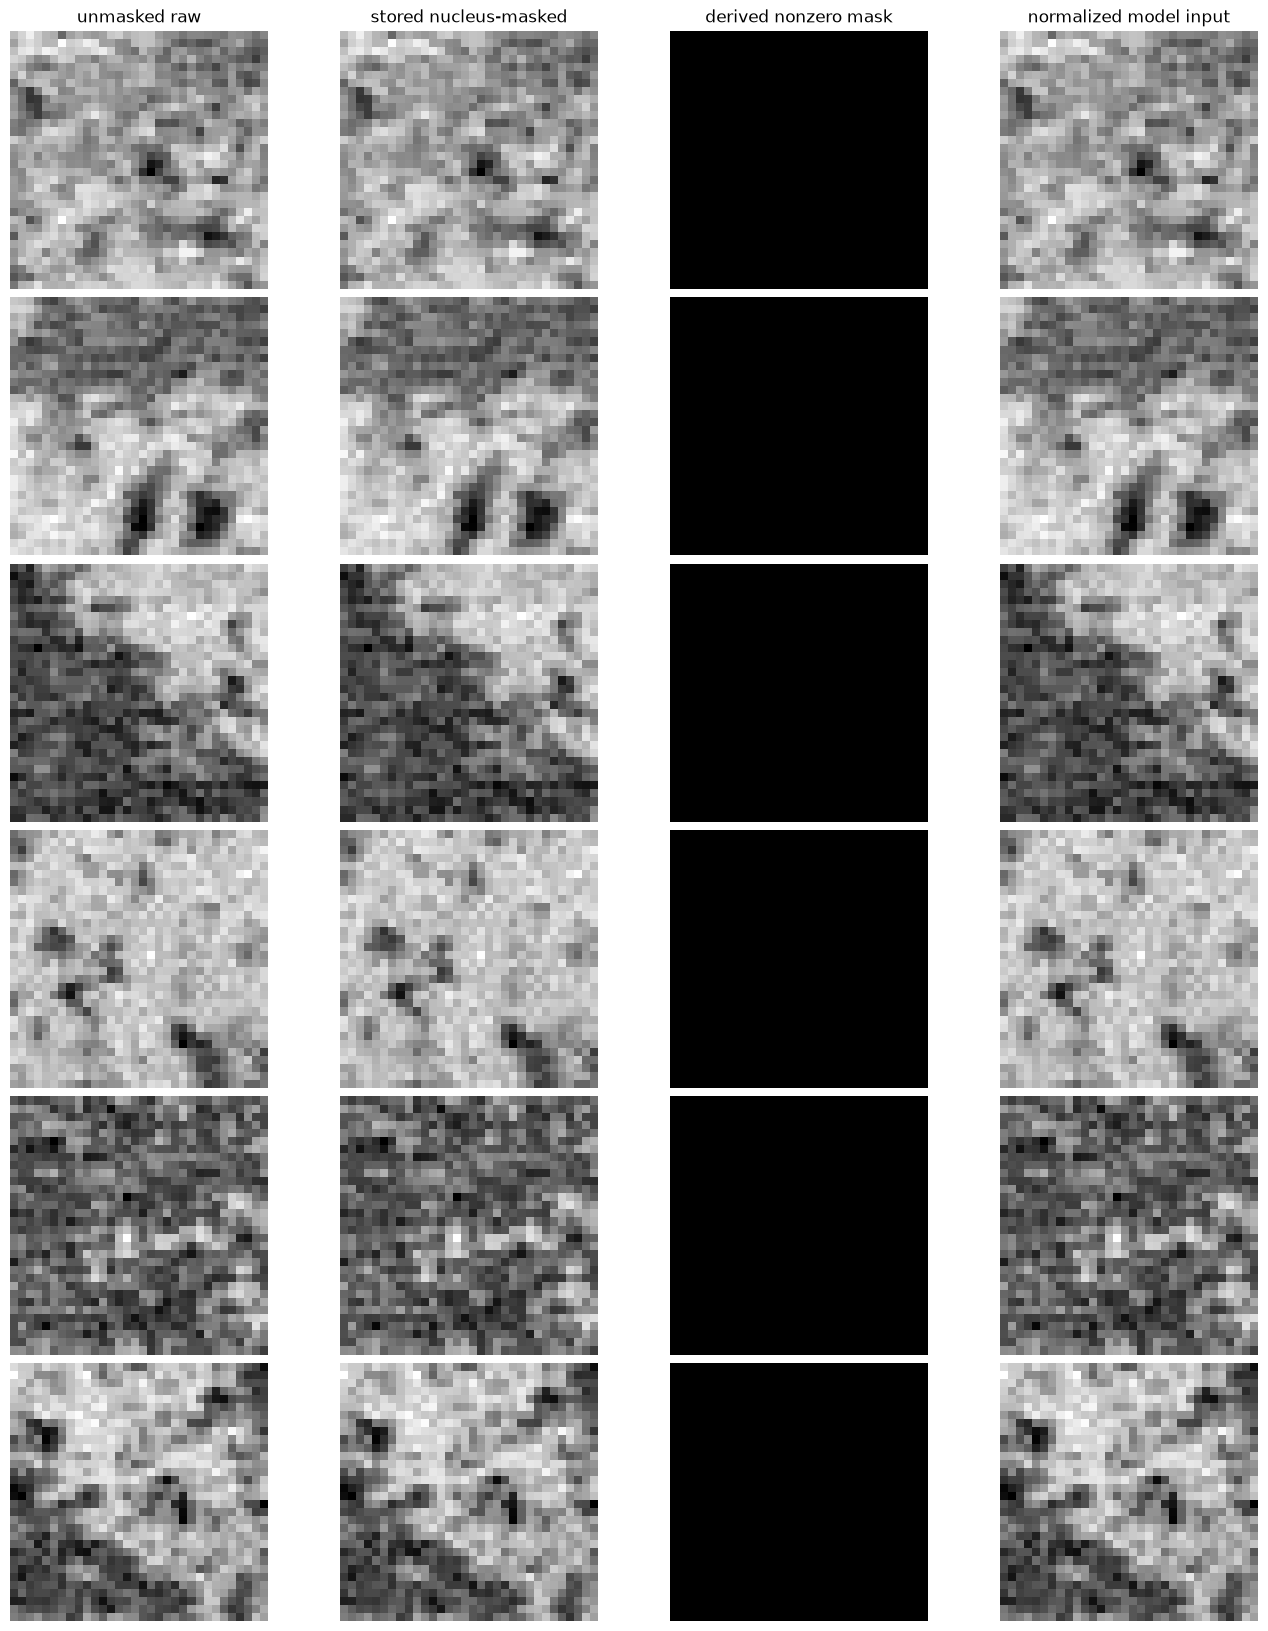

stored nonzero values match the aligned raw source: [True, True, True, True, True, True]


In [5]:
if DATA_AVAILABLE:
    inspect_dataset = prepared.dataset("all", mode="inspect", augment=False)
    probe_items = np.linspace(0, len(inspect_dataset) - 1, 6, dtype=int)
    probe_qc = [inspect_dataset.read_sample(int(item))[2] for item in probe_items]
    actual_patch_rows = [row.patch_index for row in probe_qc]
    views = read_patch_qc_views(prepared, actual_patch_rows)

    z = views["masked"].shape[1] // 2
    has_raw = views["raw"] is not None
    columns = 4 if has_raw else 3
    fig, axes = plt.subplots(len(actual_patch_rows), columns, figsize=(3.3 * columns, 2.7 * len(actual_patch_rows)), constrained_layout=True)
    for row in range(len(actual_patch_rows)):
        images = []
        titles = []
        if has_raw:
            images.append(views["raw"][row, z])
            titles.append("unmasked raw")
        images.extend([views["masked"][row, z], views["loss_masks"][row, z], views["model_inputs"][row, z]])
        titles.extend(["stored nucleus-masked", "derived nonzero mask", "normalized model input"])
        for column, (image, title) in enumerate(zip(images, titles)):
            axes[row, column].imshow(image, cmap="gray")
            axes[row, column].set_axis_off()
            if row == 0:
                axes[row, column].set_title(title)
        axes[row, 0].set_ylabel(f"ID {views['label_ids'][row]} | row {actual_patch_rows[row]}")
    plt.show()
    if has_raw:
        print("stored nonzero values match the aligned raw source:", views["masked_nonzero_matches_raw"].tolist())
else:
    views = None
    print("Skipped patch gallery.")

## 5 — Quantify patch quality before deciding how to sample

The full position table is cheap enough to validate, but the patch payload is not. The next cell
performs a bounded read. Foreground fraction zero means an empty stored patch; fraction one means
the `32³` crop contains no zero-valued voxels, not necessarily that the whole window is nucleus.

The maintained sampler can replace a low-foreground candidate with another patch from the same
parent ID using a bounded deterministic search. This avoids identity corruption and endless I/O,
but the rejected/replacement rate should still be monitored.

,patch_index,label_id,minimum,maximum,mean,standard_deviation,foreground_fraction
count,9.600000e+01,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000
mean,1.224351e+06,13107.718750,95.958333,215.052083,161.722459,18.721279,0.984904
std,7.269109e+05,9469.753932,27.908088,8.667386,15.044250,12.857811,0.073801
min,9.400000e+01,3.000000,0.000000,195.000000,77.225372,8.194836,0.494141
25%,6.140142e+05,5029.750000,92.000000,210.000000,157.492958,13.349280,1.000000
50%,1.204244e+06,11050.500000,103.000000,215.000000,162.937317,16.354392,1.000000
75%,1.837422e+06,20342.250000,112.000000,220.000000,169.320580,18.894395,1.000000
max,2.506326e+06,32698.000000,128.000000,238.000000,186.620300,82.109086,1.000000


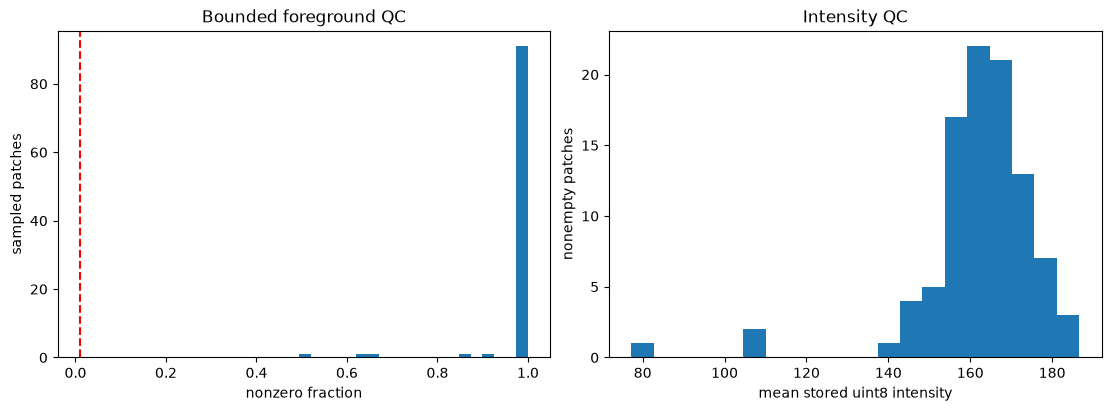

patch count per ID percentiles: {0: np.int64(35), 25: np.int64(190), 50: np.int64(212), 75: np.int64(235), 95: np.int64(324), 100: np.int64(1140)}


In [6]:
if DATA_AVAILABLE:
    qc_rows = pd.DataFrame(summarize_patch_qc(prepared.dataset("all", "inspect"), max_samples=96))
    display(qc_rows.describe())
    fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
    axes[0].hist(qc_rows["foreground_fraction"], bins=20)
    axes[0].axvline(config.data["min_foreground_fraction"], color="red", linestyle="--")
    axes[0].set(xlabel="nonzero fraction", ylabel="sampled patches", title="Bounded foreground QC")
    nonempty = qc_rows[qc_rows["foreground_fraction"] > 0]
    axes[1].hist(nonempty["mean"], bins=20)
    axes[1].set(xlabel="mean stored uint8 intensity", ylabel="nonempty patches", title="Intensity QC")
    plt.show()

    counts = prepared.index.counts
    print("patch count per ID percentiles:", dict(zip([0, 25, 50, 75, 95, 100], np.percentile(counts, [0, 25, 50, 75, 95, 100]).astype(int))))
else:
    qc_rows = pd.DataFrame()
    print("Skipped bounded quality control.")

## 6 — Split parent IDs before selecting repeated patches

A random patch split would leak texture from the same nucleus into training and validation. The
package first shuffles unique parent IDs with a fixed seed, then selects a bounded number of patch
rows inside each group. The manifest is the durable record of that decision.

In [7]:
if DATA_AVAILABLE:
    split_path = save_split_manifest(prepared)
    split_manifest = pd.read_csv(split_path, sep="	")
    display(split_manifest.groupby("split").agg(
        label_ids=("label_id", "count"),
        available_patches=("available_patches", "sum"),
        selected_patches=("selected_training_patches", "sum"),
    ))
    train_ids = set(prepared.label_splits["train"])
    validation_ids = set(prepared.label_splits["validation"])
    test_ids = set(prepared.label_splits["test"])
    assert train_ids.isdisjoint(validation_ids | test_ids)
    assert validation_ids.isdisjoint(test_ids)
    print("no parent label_id leakage; manifest:", split_path)
else:
    print("Skipped grouped split.")

,label_ids,available_patches,selected_patches
split,,,
test,1000,219550,191778
train,8000,1765571,1526839
validation,1000,217665,191178


no parent label_id leakage; manifest: /g/kreshuk/frazer/projects/MorphoFeatures/outputs/notebooks/04_real_nucleus_mae/full_grouped_patch_v10/split_manifest.tsv


## 7 — Compare legacy and maintained preprocessing

| Decision | Verified legacy experiment | Maintained grouped-patch MAE v3 |
|---|---|---|
| unit presented to transformer | up to 200 patches forming one nucleus | up to `group_size` complete patches from one nucleus |
| mask construction | hides whole local-patch tokens | hides whole `32³` texture-patch tokens |
| normalization | `uint8 / 255` in raw-patch loader | same `dtype` default; percentile/z-score are explicit alternatives |
| validation | many runs sampled all 11,382 nuclei | parent-ID train/validation/test split |
| reconstruction target | each hidden patch downsampled to `8³` | same, configured by `reconstruction_shape` |
| final feature | nucleus-level encoder representation | one nucleus-level encoder representation |

Spatial augmentation is disabled for v3: rotating patch pixels without applying the identical
physical transform to every patch coordinate would corrupt the spatial context.

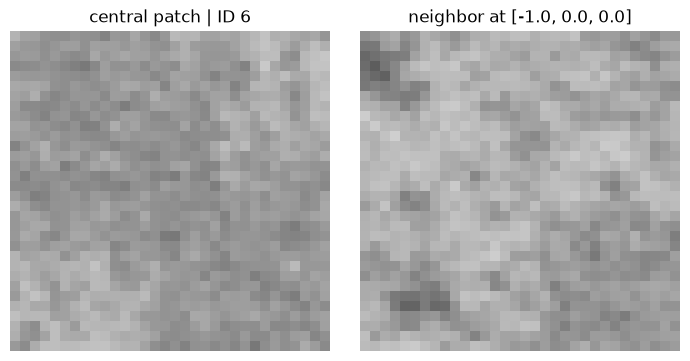

In [8]:
if DATA_AVAILABLE:
    grouped_dataset = prepared.dataset("train", "inspect", augment=False)
    group = grouped_dataset.read_group(0)
    first, second = group["patches"][0, 0], group["patches"][1, 0]
    z = first.shape[0] // 2
    fig, axes = plt.subplots(1, 2, figsize=(7, 3.5), constrained_layout=True)
    axes[0].imshow(first[z], cmap="gray", vmin=0, vmax=1)
    axes[0].set_title(f"central patch | ID {group['label_id']}")
    axes[1].imshow(second[z], cmap="gray", vmin=0, vmax=1)
    axes[1].set_title(f"neighbor at {group['positions_zyx'][1].tolist()}")
    for axis in axes:
        axis.set_axis_off()
    plt.show()
else:
    print("Skipped grouped-patch inspection.")

## 8 — Construct the MAE and account for every important dimension

Each token is one complete stored `32³` patch. The quick profile presents 64 spatially central
patches from the same nucleus; the full profile presents up to 200. The **patch encoder** maps each
`32³` array to one token. `linear` flattens the patch and uses one dense projection: every voxel can
interact immediately, but locality is not built in. `resnet3d` instead uses 3D convolutions, residual
blocks, downsampling, and global pooling. It therefore biases the token toward local motifs and
hierarchical texture. GroupNorm keeps it stable with small/variable visible-patch batches.

The nucleus-level transformer is unchanged: it sees only visible patch tokens plus their actual
relative `(z,y,x)` positions. The decoder predicts the configured lower-resolution target for each
hidden patch. Thus `patch_encoder` isolates the local-texture ablation while keeping the masking and
biological sampling unit fixed. Existing v3 linear checkpoints retain their state-dict layout.

In [9]:
if DATA_AVAILABLE:
    model = build_mae_model(dict(config.values))
    input_shape = np.asarray(config.values["mae"]["input_shape"])
    reconstruction_shape = np.asarray(config.values["mae"]["reconstruction_shape"])
    model_summary = pd.Series({
        "input z,y,x": tuple(input_shape),
        "one token z,y,x": tuple(input_shape),
        "reconstruction target z,y,x": tuple(reconstruction_shape),
        "tokens per nucleus": config.data["group_size"],
        "mask ratio": config.values["mae"]["mask_ratio"],
        "patch encoder": config.values["mae"]["patch_encoder"],
        "ResNet channels": tuple(config.values["mae"]["resnet_channels"]),
        "ResNet blocks/stage": tuple(config.values["mae"]["resnet_blocks"]),
        "embedding dimension": config.values["mae"]["embedding_dim"],
        "encoder depth": config.values["mae"]["encoder_depth"],
        "trainable parameters": sum(parameter.numel() for parameter in model.parameters()),
    }, name="value")
    display(model_summary.to_frame())
else:
    model = None
    print("Skipped model construction.")

/g/kreshuk/frazer/projects/MorphoFeatures/morphofeatures/mae3d.py:400: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=int(encoder_depth))
/g/kreshuk/frazer/projects/MorphoFeatures/morphofeatures/mae3d.py:416: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.decoder = nn.TransformerEncoder(decoder_layer, num_layers=int(decoder_depth))


,value
"input z,y,x","(32, 32, 32)"
"one token z,y,x","(32, 32, 32)"
"reconstruction target z,y,x","(8, 8, 8)"
tokens per nucleus,200
mask ratio,0.75
patch encoder,linear
ResNet channels,"(16, 32, 64)"
ResNet blocks/stage,"(1, 1, 1)"
embedding dimension,160
encoder depth,4


## 9 — Run the quick training profile interactively

By default this cell trains only when `PROFILE == "quick"` and the external data are mounted.
It reuses an existing checkpoint instead of silently retraining. If metrics exist without a final
checkpoint, choose a new run directory or set `training.resume_from` explicitly; do not merge two
experiments into one metric stream.

The quick run proves lazy reads, optimization, validation, checkpoint portability, and ID
propagation. Whether two portable or 50 site-profile epochs run, this remains a workflow check,
not evidence of useful biology.

In [10]:
RUN_QUICK_TRAINING = True
REUSE_EXISTING = True
#checkpoint_path = config.checkpoint_path if DATA_AVAILABLE else None
checkpoint_path = Path("/g/kreshuk/frazer/projects/MorphoFeatures/outputs/experiments/mae-trial2/mae_train/checkpoints/checkpoint-best.pt")
if DATA_AVAILABLE and PROFILE == "quick" and RUN_QUICK_TRAINING:
    if checkpoint_path.exists() and REUSE_EXISTING:
        print("reusing checkpoint:", checkpoint_path)
    elif config.metrics_path.exists():
        raise RuntimeError(
            "Metrics exist without a reusable final checkpoint. Choose a new paths.run_dir or configure resume_from."
        )
    else:
        checkpoint_path = train_real_mae(config)
    display(pd.Series(inspect_checkpoint(checkpoint_path)).to_frame("value"))
elif DATA_AVAILABLE:
    print("Interactive training skipped. Use the SLURM preview below for the full profile.")
else:
    print("Training skipped: external data are unavailable.")

Interactive training skipped. Use the SLURM preview below for the full profile.


## 10 — Monitor structured metrics and select a checkpoint

Metrics are append-only JSON Lines, so a running job can be inspected even if its final line is
partially written. A falling training curve alone can reflect memorization. The validation curve,
held-out reconstructions, and downstream stability matter together.

In [24]:
if DATA_AVAILABLE and config.metrics_path.exists():
    events = read_metric_events(config.metrics_path)
    metrics = pd.DataFrame(metric_series(events))
    metric_columns = ["epoch", "step", "train_loss", "validation_loss", "validation_visible_mean_baseline_loss", "validation_improvement_over_visible_mean", "learning_rate", "timestamp"]
    display(metrics[[column for column in metric_columns if column in metrics]])
    plotted = [column for column in ["train_loss", "validation_loss", "validation_visible_mean_baseline_loss"] if column in metrics]
    axis = metrics.plot(x="epoch", y=plotted, marker="o", figsize=(7, 4))
    axis.set_ylabel("masked-patch reconstruction loss")
    axis.set_title("Optimization diagnostic, not evidence of useful biology")
    axis.grid(alpha=0.25)
    plt.show()
else:
    metrics = pd.DataFrame()
    print("No metrics artifact is available yet.")

No metrics artifact is available yet.


## 11 — Inspect held-out masking and reconstruction

Here the masking unit is a complete stored texture patch, so the target panel is entirely hidden.
A visible neighboring patch supplies spatial context; target and prediction are both the audited
`8³` reconstruction scale. With normalized-pixel loss, a no-information prediction has loss near
one. Look for position-dependent low-resolution structure, not exact stochastic EM texture.

In [13]:
if DATA_AVAILABLE and checkpoint_path is not None and checkpoint_path.exists():
    recon = reconstruct_real_samples(config, checkpoint_path, split="test", count=1)
    model_mse = float(recon["hidden_patch_normalized_mse"])
    baseline_mse = float(recon["visible_patch_mean_baseline_mse"])
    print(f"hidden-patch normalized MSE: {model_mse:.6f}")
    print(f"visible-patch mean baseline MSE: {baseline_mse:.6f}")
    print(f"improvement over baseline: {1 - model_mse / max(baseline_mse, 1e-12):.1%}")
    z = recon["inputs"].shape[-3] // 2
    fig, axes = plt.subplots(len(recon["label_ids"]), 5, figsize=(15, 3 * len(recon["label_ids"])), constrained_layout=True)
    for row, label_id in enumerate(recon["label_ids"]):
        target = recon["inputs"][row, 0, z]
        prediction = recon["reconstructions"][row, 0, z]
        foreground = recon["foreground_masks"][row, 0, z]
        images = [target, recon["visible_context"][row, 0, z], prediction, np.abs(prediction - target), foreground]
        titles = ["hidden target (8³)", "one visible neighbor", "prediction", "absolute error", "target nonzero"]
        cmaps = ["gray", "gray", "gray", "magma", "Reds"]
        for column, (image, title, cmap) in enumerate(zip(images, titles, cmaps)):
            limits = {"vmin": 0, "vmax": 1} if cmap == "gray" else {}
            axes[row, column].imshow(image, cmap=cmap, **limits)
            axes[row, column].set_axis_off()
            if row == 0:
                axes[row, column].set_title(title)
        axes[row, 0].set_ylabel(f"ID {label_id} | pos {recon['hidden_positions_zyx'][row].tolist()}")
    plt.show()
else:
    recon = None
    print("Reconstruction QC requires a checkpoint.")

/g/kreshuk/frazer/projects/MorphoFeatures/morphofeatures/mae3d.py:400: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=int(encoder_depth))
/g/kreshuk/frazer/projects/MorphoFeatures/morphofeatures/mae3d.py:416: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.decoder = nn.TransformerEncoder(decoder_layer, num_layers=int(decoder_depth))


AcceleratorError: CUDA error: out of memory
Search for `cudaErrorMemoryAllocation' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
For more detailed error information, run with CUDA_LOG_FILE=stderr


## 12 — Preview a realistic SLURM run; never submit on cell rerun

The maintained planner constructs an argument list, validates the resolved full configuration,
quotes the shell script, separates stdout/stderr, and reserves an experiment directory. The
profile contains placeholders—replace partition/account/QoS and the reviewed activation script.

The submission guard requires both a boolean and an exact confirmation phrase. Automated notebook
execution and ordinary cell reruns therefore cannot submit. The SQLite registry survives kernel
and Streamlit restarts. Use the Streamlit workspace for routine monitoring, cancellation, and
dependent encoding jobs.

In [ ]:
slurm_plan = None
if DATA_AVAILABLE:
    full_output = REPO_ROOT / "outputs" / "real_mae" / "platynereis_nucleus_texture_full"
    full_config = resolve_real_mae_config(
        CONFIG_PATH,
        profile="full",
        overrides={"paths": {"run_dir": str(full_output)}},
        require_data=True,
    )
    full_config_path = full_config.save(full_output / "resolved_config.yaml")
    cluster_profile = ClusterProfile.from_mapping("notebook-preview", full_config.values["slurm"])
    request = WorkflowRequest("mae_train", full_config_path, device=str(full_config.values["device"]))
    slurm_plan = plan_job(
        request,
        cluster_profile,
        run_id="platynereis-nucleus-mae-full",
        output_root=REPO_ROOT / "outputs",
    )
    print("Exact argument list:")
    print(list(slurm_plan.command))
    print()
    print("Generated SLURM script:")
    print()
    print(slurm_plan.script)
else:
    print("SLURM preview requires valid external paths.")

In [ ]:
# Deliberately safe defaults. Editing only one of these values is insufficient.
SUBMIT_TO_SLURM = False
SUBMISSION_CONFIRMATION = ""

if SUBMIT_TO_SLURM:
    if SUBMISSION_CONFIRMATION != "SUBMIT FULL PLATYNEREIS NUCLEUS MAE":
        raise RuntimeError("Set the exact confirmation phrase shown in this cell.")
    if slurm_plan is None:
        raise RuntimeError("Create a valid plan before submission.")
    if not SlurmScheduler.available():
        raise RuntimeError("sbatch is unavailable; keep this as a dry-run preview.")
    registry = JobRegistry(REPO_ROOT / "outputs" / "experiments.sqlite")
    submitted = submit_plan(slurm_plan, registry, SlurmScheduler(), repository=REPO_ROOT)
    display(pd.Series(submitted.__dict__).to_frame("value"))
else:
    print("Not submitted. Preview only.")

## 12b — Optionally compare architectures with a bounded soft grid

`configs/mae_nucleus_soft_grid.example.yaml` uses **one-at-a-time** ablations by default:
baseline plus one changed value per run. That is slower than changing everything at once, but it
makes a difference attributable to learning rate, scheduler, patch encoder, dimension, target
shape, or normalization. `cartesian` is available but the resolver enforces `max_runs` (at most 64).
Only documented parameter paths are accepted; this is not a shell-command generator.

Preparing writes immutable resolved configs and a manifest but submits nothing. Each training job
uses the same registry/SLURM planner as the single run. Optional encoders are separate `afterok`
jobs. Change the sweep name before a new experiment rather than overwriting an old manifest.

In [ ]:
SOFT_GRID_SPEC = REPO_ROOT / "configs" / "mae_nucleus_soft_grid.example.yaml"
SOFT_GRID_MANIFEST = REPO_ROOT / "outputs" / "sweeps" / "nucleus-local-texture-ablation" / "manifest.json"
PREPARE_SOFT_GRID = False  # writes configs/manifest, but never submits
SUBMIT_SOFT_GRID = False
SOFT_GRID_CONFIRMATION = ""
ENCODE_AFTER_TRAINING = True

soft_grid = None
soft_grid_plans = ()
if DATA_AVAILABLE and PREPARE_SOFT_GRID:
    soft_grid = prepare_soft_grid(
        CONFIG_PATH, SOFT_GRID_SPEC, output_root=REPO_ROOT / "outputs", profile=PROFILE
    )
elif SOFT_GRID_MANIFEST.exists():
    soft_grid = load_prepared_sweep(SOFT_GRID_MANIFEST)

if soft_grid is not None and DATA_AVAILABLE:
    soft_grid_plans = plan_soft_grid(
        soft_grid, cluster_profile, output_root=REPO_ROOT / "outputs"
    )
    display(pd.DataFrame([
        {"variant": variant.name, "run_id": variant.run_id, "overrides": dict(variant.overrides)}
        for variant in soft_grid.variants
    ]))
    print("First generated script (all scripts are available in soft_grid_plans):")
    print(soft_grid_plans[0].script)
else:
    print("No sweep prepared. Inspect the YAML, choose a new name, then set PREPARE_SOFT_GRID=True once.")

if SUBMIT_SOFT_GRID:
    if SOFT_GRID_CONFIRMATION != "SUBMIT PLATYNEREIS MAE SOFT GRID":
        raise RuntimeError("Set the exact soft-grid confirmation phrase in this cell.")
    if not soft_grid_plans or not SlurmScheduler.available():
        raise RuntimeError("A prepared grid and an available sbatch command are required.")
    sweep_registry = JobRegistry.under_output_root(REPO_ROOT / "outputs")
    sweep_records = submit_soft_grid(
        soft_grid_plans, sweep_registry, SlurmScheduler(), repository=REPO_ROOT,
        encode_after_training=ENCODE_AFTER_TRAINING,
    )
    display(pd.DataFrame([record.__dict__ for record in sweep_records]))
else:
    print("Soft grid not submitted. Preview only.")

## 13 — Encode and validate the label-first contract

Each nucleus group is encoded without masking to one sequence-level representation, keyed by the
stored parent ID and shaped `(n_labels, 1 + embedding_dim)`. Column zero is integer-valued and unique;
`label_id`; every feature must be finite. Aggregation never assumes that two tables share row
order.

In [14]:
embedding = None
REUSE_EXISTING = False
if DATA_AVAILABLE and checkpoint_path is not None and checkpoint_path.exists():
    if config.embedding_path.exists() and REUSE_EXISTING:
        embedding_path = config.embedding_path
    else:
        embedding_path = encode_real_mae(config, checkpoint_path)
    embedding = load_embeddings(embedding_path)
    summary = inspect_embedding(embedding_path)
    display(pd.Series(summary.to_dict()).to_frame("value"))
    expected_ids = np.sort(np.concatenate(list(prepared.label_splits.values())))
    assert np.array_equal(embedding.label_ids, expected_ids)
    assert np.all(np.isfinite(embedding.features))
    print("exact ID coverage and finite label-first features confirmed")
else:
    embedding_path = None
    print("Encoding requires a completed checkpoint.")

AcceleratorError: CUDA error: out of memory
Search for `cudaErrorMemoryAllocation' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
For more detailed error information, run with CUDA_LOG_FILE=stderr


In [11]:
import torch

from morphofeatures.mae3d import build_mae_model, load_mae_checkpoint

#prepared = prepare_real_mae_data(config)
prepared


PreparedRealMAEData(config=ResolvedRealMAEConfig(values={'seed': 42, 'device': 'cuda', 'active_profile': 'full', 'data': {'source': 'n5_masked_patches', 'patches_container': '/g/kreshuk/mansaray/raw_patches_masked.n5', 'patches_key': 'patches', 'positions_container': '/g/kreshuk/mansaray/abs_crop_centers_radius4_only_nucl.n5', 'positions_key': 'positions', 'ids_key': 'ids', 'qc_raw_container': '/g/kreshuk/data/arendt/platyneris_v1/data.n5', 'qc_raw_key': 'volumes/raw/s1', 'position_radius_zyx': [4, 4, 4], 'position_to_raw_scale_zyx': [4, 4, 4], 'modality': 'EM', 'biological_unit': 'nucleus', 'axes': 'zyx', 'resolution_zyx_um': [0.025, 0.02, 0.02], 'position_resolution_zyx_um': [0.1, 0.08, 0.08], 'patch_shape_zyx': [32, 32, 32], 'mask_mode': 'nonzero', 'normalization': 'dtype', 'min_foreground_fraction': 0.01, 'group_size': 200, 'position_stride_zyx': [8, 8, 8]}, 'split': {'train_fraction': 0.8, 'validation_fraction': 0.1, 'test_fraction': 0.1, 'max_labels': 10000}, 'augmentation': {'ra

In [ ]:
    inference = config.values["inference"]
    inference = {'batch_size': 16, 'workers': 1, 'split': 'all'}


In [ ]:
split = str(inference["split"])
dataset = prepared.dataset(split, "encode", augment=False)
dataset


In [14]:
from morphofeatures.real_mae import _data_loader
loader = _data_loader(
    dataset,
    inference,
    shuffle=False,
    seed=int(config.values["seed"]),
)
loader

In [17]:
from morphofeatures.real_mae import resolve_device
device = resolve_device(str(config.values["device"]))
model = build_mae_model(dict(config.values)).to(device)
load_mae_checkpoint(Path(checkpoint_path), model, device=device)
model.eval()

/g/kreshuk/frazer/projects/MorphoFeatures/morphofeatures/mae3d.py:400: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=int(encoder_depth))
/g/kreshuk/frazer/projects/MorphoFeatures/morphofeatures/mae3d.py:416: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.decoder = nn.TransformerEncoder(decoder_layer, num_layers=int(decoder_depth))


GroupedPatchMaskedAutoencoder3D(
  (patch_encoder): Sequential(
    (0): Flatten(start_dim=2, end_dim=-1)
    (1): Linear(in_features=32768, out_features=160, bias=True)
  )
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=160, out_features=160, bias=True)
        )
        (linear1): Linear(in_features=160, out_features=640, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
        (linear2): Linear(in_features=640, out_features=160, bias=True)
        (norm1): LayerNorm((160,), eps=1e-05, elementwise_affine=True, bias=True)
        (norm2): LayerNorm((160,), eps=1e-05, elementwise_affine=True, bias=True)
        (dropout1): Dropout(p=0.0, inplace=False)
        (dropout2): Dropout(p=0.0, inplace=False)
      )
    )
  )
  (encoder_norm): LayerNorm((160,), eps=1e-05, elementwise_affine=True, bias=True)
  (decoder_proje

In [ ]:
ids = []
feature_batches = []
valid_patch_counts = []
with torch.no_grad():
    for label_ids, patches, positions, valid in loader:
        features = model.encode(
            patches.to(device, non_blocking=True),
            positions.to(device, non_blocking=True),
            valid.to(device, non_blocking=True),
        ).cpu().numpy()
        ids.append(label_ids.numpy())
        feature_batches.append(features)
        valid_patch_counts.append(valid.sum(dim=1).numpy())
ids = np.concatenate(ids).astype(np.int64, copy=False)
features = np.concatenate(feature_batches)
valid_counts = np.concatenate(valid_patch_counts).astype(np.int64, copy=False)



In [22]:
from morphofeatures.real_mae import export_embeddings

In [25]:
order = np.argsort(ids)
ids, features, valid_counts = ids[order], features[order], valid_counts[order]
expected = (
    np.sort(np.concatenate(list(prepared.label_splits.values())))
    if split == "all"
    else prepared.label_splits[split]
)
if not np.array_equal(ids, expected):
    raise ValueError("Aggregated embedding IDs do not exactly cover the configured label split")
destination = Path(config.embedding_path)
export_embeddings(destination, ids, features)
metadata_path = destination.with_suffix(destination.suffix + ".metadata.json")
write_json_atomic(
    metadata_path,
    {
        "artifact_type": "label_first_embedding",
        "scope": "nucleus-derived EM texture",
        "mae_architecture_version": 'v3',
        "patch_encoder": str(config.values["mae"]["patch_encoder"]),
        "checkpoint": str(Path(checkpoint_path).resolve()),
        "rows": int(len(ids)),
        "features": int(features.shape[1]),
        "label_ids_unique": True,
        "finite": bool(np.all(np.isfinite(features))),
        "group_size": int(config.data["group_size"]),
        "valid_patches_per_label": {
            str(label_id): int(count) for label_id, count in zip(ids, valid_counts)
        },
    },
)
run_metadata_path = Path(config.values["paths"]["run_metadata"])
if run_metadata_path.exists():
    metadata = json.loads(run_metadata_path.read_text(encoding="utf-8"))
    metadata.setdefault("artifacts", {}).update(
        {"embedding": str(destination), "embedding_metadata": str(metadata_path)}
    )
    write_json_atomic(run_metadata_path, metadata)

In [26]:
embedding = load_embeddings(destination)


## 14 — Explore structure, then join annotations by `label_id`

Standardization prevents high-variance learned dimensions from dominating Euclidean distance.
PCA is deterministic and appropriate for the tiny quick cohort; UMAP can be added for the full
cohort. K-means labels are descriptive partitions, not discovered cell types. Biological
annotation is merged by `label_id`, never assigned by row position.

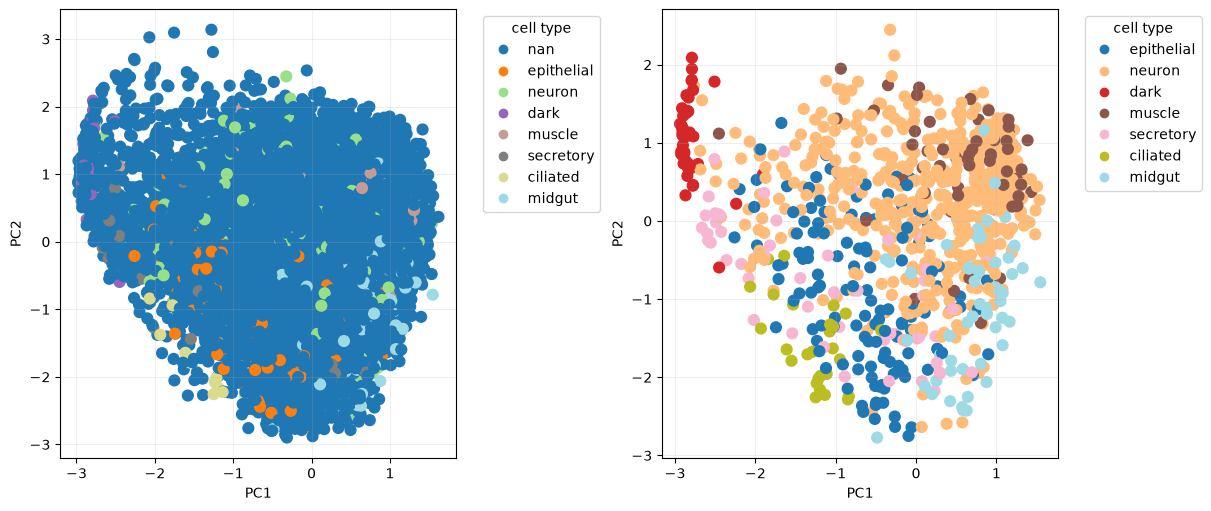

,label_id,mae_pc1,mae_pc2,mae_pc3,mae_kmeans_cluster,split,cell_type,anchor_x,anchor_y,anchor_z,n_pixels
0,3,0.111545,-0.880651,-0.612945,3,validation,NaN,212.828043,150.699916,7.712404,45798972.0
1,4,-0.229954,-1.885080,-0.290592,3,validation,NaN,211.769084,145.632560,8.160763,16698877.0
2,6,-0.270345,1.062038,-0.403446,0,train,NaN,196.383898,152.496323,5.875171,20926216.0
3,8,-0.117228,0.097732,-0.818087,0,test,NaN,201.669790,148.862645,5.201383,20030000.0
4,9,-0.032668,-0.817841,-1.213550,3,train,NaN,202.510578,148.489723,8.618814,22214740.0


In [38]:
analysis_frame = None
if embedding is not None:
    standardized = StandardScaler().fit_transform(embedding.features)
    coordinates = PCA(n_components=10, random_state=SEED, svd_solver="full", whiten=True).fit_transform(standardized)
    n_clusters = min(4, max(2, len(embedding.label_ids) // 5))
    clusters = KMeans(n_clusters=n_clusters, random_state=SEED, n_init=20).fit_predict(standardized)
    split_by_id = {int(label_id): split for split, ids in prepared.label_splits.items() for label_id in ids}
    analysis_frame = pd.DataFrame({
        "label_id": embedding.label_ids,
        "mae_pc1": coordinates[:, 0],
        "mae_pc2": coordinates[:, 1],
        "mae_pc3": coordinates[:, 2],
        "mae_kmeans_cluster": clusters,
        "split": [split_by_id[int(label_id)] for label_id in embedding.label_ids],
    })
    cell_table_path = config.values.get("annotations", {}).get("cell_table")
    if cell_table_path:
        cell_table = pd.read_csv(cell_table_path, sep="	")
        cell_table["label_id"] = cell_table["label_id"].round().astype("int64")
        keep = [column for column in ["label_id", "cell_type", "anchor_x", "anchor_y", "anchor_z", "n_pixels"] if column in cell_table]
        analysis_frame = analysis_frame.merge(cell_table[keep], on="label_id", how="left", validate="one_to_one")

    
    unique_cell_types =[cell_type for cell_type in analysis_frame["cell_type"].unique()]
    cell_type_map = {cell_type: i for i, cell_type in enumerate(unique_cell_types)}
    cell_type_numerical = []
    for cell in analysis_frame["cell_type"]:
        cell_type_numerical.append(cell_type_map[cell]) 
    cell_type_counts = analysis_frame["cell_type"].value_counts()
    filtered_analysis_frame = analysis_frame[analysis_frame["cell_type"].notnull()]
    filtered_cell_type_numerical = []
    for cell in filtered_analysis_frame["cell_type"]:
        filtered_cell_type_numerical.append(cell_type_map[cell])
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
    axes[0].scatter(analysis_frame["mae_pc1"], analysis_frame["mae_pc2"], c=cell_type_numerical, cmap="tab20", s=60)
    axes[0].legend(handles=axes[0].collections[0].legend_elements()[0], labels=unique_cell_types, title="cell type", bbox_to_anchor=(1.05, 1), loc="upper left")
    
    axes[1].scatter(filtered_analysis_frame["mae_pc1"], filtered_analysis_frame["mae_pc2"], c=filtered_cell_type_numerical, cmap="tab20", s=60)
    axes[1].legend(handles=axes[1].collections[0].legend_elements()[0], labels=unique_cell_types[1:], title="cell type", bbox_to_anchor=(1.05, 1), loc="upper left")
    for axis in axes:
        axis.set(xlabel="PC1", ylabel="PC2")
        axis.grid(alpha=0.2)
    plt.show()
    display(analysis_frame.head())
else:
    print("Downstream analysis requires embeddings.")

In [ ]:
from umap import UMAP

coordinates_umap = UMAP(n_neighbors=15, n_components=2, random_state=SEED).fit_transform(standardized)

/g/kreshuk/frazer/miniforge3/envs/MorphoFeats_dev/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


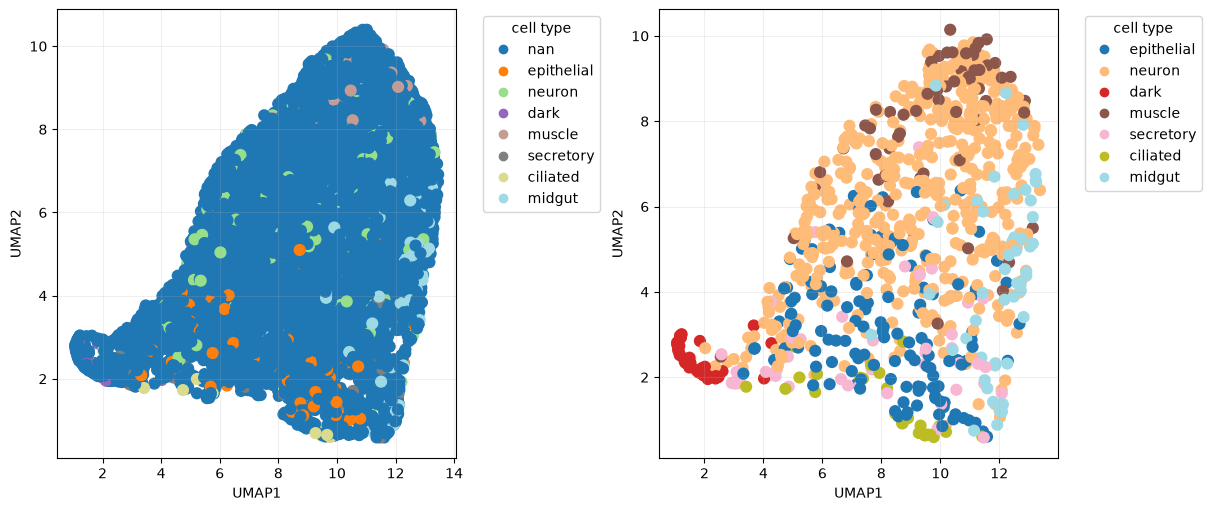

,label_id,mae_pc1,mae_pc2,mae_kmeans_cluster,split,cell_type,anchor_x,anchor_y,anchor_z,n_pixels
0,3,9.910790,3.883204,3,validation,NaN,212.828043,150.699916,7.712404,45798972.0
1,4,9.660468,2.348791,3,validation,NaN,211.769084,145.632560,8.160763,16698877.0
2,6,7.251020,7.092373,0,train,NaN,196.383898,152.496323,5.875171,20926216.0
3,8,8.382608,5.445469,0,test,NaN,201.669790,148.862645,5.201383,20030000.0
4,9,9.035881,3.977859,3,train,NaN,202.510578,148.489723,8.618814,22214740.0


In [47]:
analysis_frame = None
if embedding is not None:
    #standardized = StandardScaler().fit_transform(embedding.features)
    #coordinates = PCA(n_components=10, random_state=SEED, svd_solver="full", whiten=True).fit_transform(standardized)
    n_clusters = min(4, max(2, len(embedding.label_ids) // 5))
    clusters = KMeans(n_clusters=n_clusters, random_state=SEED, n_init=20).fit_predict(standardized)
    split_by_id = {int(label_id): split for split, ids in prepared.label_splits.items() for label_id in ids}
    analysis_frame = pd.DataFrame({
        "label_id": embedding.label_ids,
        "mae_pc1": coordinates_umap[:, 0],
        "mae_pc2": coordinates_umap[:, 1],
        #"mae_pc3": coordinates_umap[:, 2],
        "mae_kmeans_cluster": clusters,
        "split": [split_by_id[int(label_id)] for label_id in embedding.label_ids],
    })
    cell_table_path = config.values.get("annotations", {}).get("cell_table")
    if cell_table_path:
        cell_table = pd.read_csv(cell_table_path, sep="	")
        cell_table["label_id"] = cell_table["label_id"].round().astype("int64")
        keep = [column for column in ["label_id", "cell_type", "anchor_x", "anchor_y", "anchor_z", "n_pixels"] if column in cell_table]
        analysis_frame = analysis_frame.merge(cell_table[keep], on="label_id", how="left", validate="one_to_one")

    
    unique_cell_types =[cell_type for cell_type in analysis_frame["cell_type"].unique()]
    cell_type_map = {cell_type: i for i, cell_type in enumerate(unique_cell_types)}
    cell_type_numerical = []
    for cell in analysis_frame["cell_type"]:
        cell_type_numerical.append(cell_type_map[cell]) 
    cell_type_counts = analysis_frame["cell_type"].value_counts()
    filtered_analysis_frame = analysis_frame[analysis_frame["cell_type"].notnull()]
    filtered_cell_type_numerical = []
    for cell in filtered_analysis_frame["cell_type"]:
        filtered_cell_type_numerical.append(cell_type_map[cell])
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
    axes[0].scatter(analysis_frame["mae_pc1"], analysis_frame["mae_pc2"], c=cell_type_numerical, cmap="tab20", s=60)
    axes[0].legend(handles=axes[0].collections[0].legend_elements()[0], labels=unique_cell_types, title="cell type", bbox_to_anchor=(1.05, 1), loc="upper left")
    
    axes[1].scatter(filtered_analysis_frame["mae_pc1"], filtered_analysis_frame["mae_pc2"], c=filtered_cell_type_numerical, cmap="tab20", s=60)
    axes[1].legend(handles=axes[1].collections[0].legend_elements()[0], labels=unique_cell_types[1:], title="cell type", bbox_to_anchor=(1.05, 1), loc="upper left")
    for axis in axes:
        axis.set(xlabel="UMAP1", ylabel="UMAP2")
        axis.grid(alpha=0.2)
    plt.show()
    display(analysis_frame.head())
else:
    print("Downstream analysis requires embeddings.")

In [31]:
unique_cell_types

[nan,
 'epithelial',
 'neuron',
 'dark',
 'muscle',
 'secretory',
 'ciliated',
 'midgut']

In [62]:
coordinates_umap_2 = UMAP(n_neighbors=20, n_components=2, n_epochs=1000, spread=0.5, repulsion_strength=0.5, random_state=SEED).fit_transform(standardized)

/g/kreshuk/frazer/miniforge3/envs/MorphoFeats_dev/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


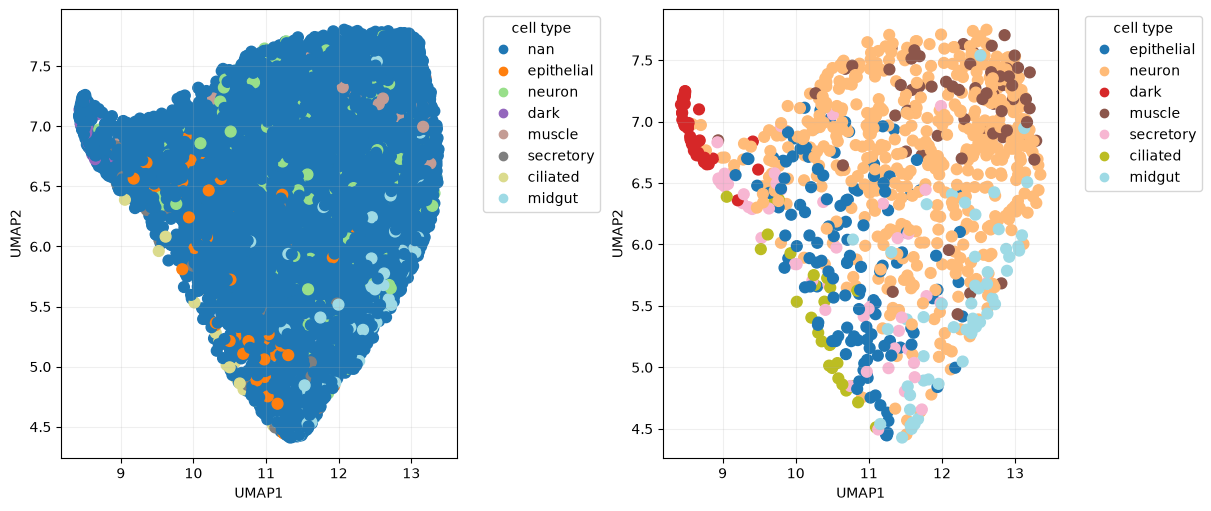

,label_id,mae_pc1,mae_pc2,mae_kmeans_cluster,split,cell_type,anchor_x,anchor_y,anchor_z,n_pixels
0,3,11.459219,5.833875,3,validation,NaN,212.828043,150.699916,7.712404,45798972.0
1,4,11.049790,5.305599,3,validation,NaN,211.769084,145.632560,8.160763,16698877.0
2,6,11.243356,7.352709,0,train,NaN,196.383898,152.496323,5.875171,20926216.0
3,8,11.300443,6.666087,0,test,NaN,201.669790,148.862645,5.201383,20030000.0
4,9,11.204477,5.996236,3,train,NaN,202.510578,148.489723,8.618814,22214740.0


In [60]:
analysis_frame = None
if embedding is not None:
    #standardized = StandardScaler().fit_transform(embedding.features)
    #coordinates = PCA(n_components=10, random_state=SEED, svd_solver="full", whiten=True).fit_transform(standardized)
    n_clusters = min(4, max(2, len(embedding.label_ids) // 5))
    clusters = KMeans(n_clusters=n_clusters, random_state=SEED, n_init=20).fit_predict(standardized)
    split_by_id = {int(label_id): split for split, ids in prepared.label_splits.items() for label_id in ids}
    analysis_frame = pd.DataFrame({
        "label_id": embedding.label_ids,
        "mae_pc1": coordinates_umap_2[:, 0],
        "mae_pc2": coordinates_umap_2[:, 1],
        #"mae_pc3": coordinates_umap_2[:, 2],
        "mae_kmeans_cluster": clusters,
        "split": [split_by_id[int(label_id)] for label_id in embedding.label_ids],
    })
    cell_table_path = config.values.get("annotations", {}).get("cell_table")
    if cell_table_path:
        cell_table = pd.read_csv(cell_table_path, sep="	")
        cell_table["label_id"] = cell_table["label_id"].round().astype("int64")
        keep = [column for column in ["label_id", "cell_type", "anchor_x", "anchor_y", "anchor_z", "n_pixels"] if column in cell_table]
        analysis_frame = analysis_frame.merge(cell_table[keep], on="label_id", how="left", validate="one_to_one")

    
    unique_cell_types =[cell_type for cell_type in analysis_frame["cell_type"].unique()]
    cell_type_map = {cell_type: i for i, cell_type in enumerate(unique_cell_types)}
    cell_type_numerical = []
    for cell in analysis_frame["cell_type"]:
        cell_type_numerical.append(cell_type_map[cell]) 
    cell_type_counts = analysis_frame["cell_type"].value_counts()
    filtered_analysis_frame = analysis_frame[analysis_frame["cell_type"].notnull()]
    filtered_cell_type_numerical = []
    for cell in filtered_analysis_frame["cell_type"]:
        filtered_cell_type_numerical.append(cell_type_map[cell])
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
    axes[0].scatter(analysis_frame["mae_pc1"], analysis_frame["mae_pc2"], c=cell_type_numerical, cmap="tab20", s=60)
    axes[0].legend(handles=axes[0].collections[0].legend_elements()[0], labels=unique_cell_types, title="cell type", bbox_to_anchor=(1.05, 1), loc="upper left")
    
    axes[1].scatter(filtered_analysis_frame["mae_pc1"], filtered_analysis_frame["mae_pc2"], c=filtered_cell_type_numerical, cmap="tab20", s=60)
    axes[1].legend(handles=axes[1].collections[0].legend_elements()[0], labels=unique_cell_types[1:], title="cell type", bbox_to_anchor=(1.05, 1), loc="upper left")
    for axis in axes:
        axis.set(xlabel="UMAP1", ylabel="UMAP2")
        axis.grid(alpha=0.2)
    plt.show()
    display(analysis_frame.head())
else:
    print("Downstream analysis requires embeddings.")

In [61]:
filtered_analysis_frame.shape

(887, 10)

## 15 — Compare completed soft-grid runs quantitatively and visually

The summary reports final and best raw losses, the visible-neighbor baseline improvement, and
artifact availability. Curves reveal unstable or differently paced optimization. Matched held-out
reconstructions reveal whether a low scalar loss corresponds to recognizable low-resolution spatial
structure. Neither view alone selects a biologically useful representation: compare embedding QC and
the same preregistered downstream task across variants as well.

Qualitative reconstruction loading is opt-in because it reloads every checkpoint and real N5 data.

In [ ]:
RUN_SWEEP_RECONSTRUCTION_COMPARISON = False
if soft_grid is not None:
    sweep_comparison_dir = soft_grid.directory / "comparison"
    sweep_summary = summarize_soft_grid(
        soft_grid, output=sweep_comparison_dir / "metrics_summary.tsv"
    )
    display(sweep_summary)
    if sweep_summary["epochs_completed"].sum():
        plot_soft_grid_metrics(soft_grid, sweep_comparison_dir / "loss_curves.png")
        plt.show()
    if sweep_summary["embedding_exists"].any():
        sweep_classifiers = compare_soft_grid_classifiers(
            soft_grid, REPO_ROOT / "analysis" / "data" / "class_labels.tsv",
            output=sweep_comparison_dir / "classifier_summary.tsv", model="logistic",
            folds=5, seed=SEED, minimum_class_count=2,
        )
        display(sweep_classifiers)
    if RUN_SWEEP_RECONSTRUCTION_COMPARISON:
        plot_soft_grid_reconstructions(
            soft_grid, sweep_comparison_dir / "held_out_reconstructions.png",
            split="test", count=2, device="cpu",
        )
        plt.show()
else:
    print("Prepare or reopen a soft-grid manifest to compare runs.")

## 16 — Probe the nucleus-embedding → cell-type association

A **linear probe** asks whether curated cell types are linearly separable in the unsupervised nucleus
embedding. `mlp` adds one shallow nonlinear hidden layer. The package intersects annotations and
embeddings by `label_id`, removes classes with fewer than two matched examples, standardizes *inside*
each cross-validation fold, and returns out-of-fold predictions and a confusion matrix.

For the 1,000-ID quick cohort, only a small subset overlaps the 390 curated labels (and some types can
have only one example), so this cell is illustrative and underpowered. The full 11,382-ID encoding is
the appropriate starting point. These labels and patches come from one animal: cross-validation tests
association within that animal, not generalization to another animal, causal mechanism, or proof that
the embedding captures cell identity rather than a correlated technical/biological variable.

In [ ]:
import sys
sys.path.append("/g/kreshuk/frazer/projects/MorphoFeatures/morphofeatures/analysis")

from morphofeatures.analysis import classification  # Now importable

ImportError: cannot import name 'classification' from 'analysis' (/g/kreshuk/frazer/projects/MorphoFeatures/analysis/__init__.py)

In [122]:
"""Configured real-data MAE workflow for grouped, masked N5 patches.

This is intentionally an adapter around :mod:`morphofeatures.mae3d`.  The
scientific model remains in that module; this one resolves configuration,
builds leakage-safe lazy datasets, manages resume/checkpoint metadata, and
aggregates patch encodings to one row per biological ``label_id``.
"""

from __future__ import annotations

import hashlib
import json
import os
import time
from collections.abc import Mapping, Sequence
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Callable

import numpy as np
import yaml

from morphofeatures.artifacts import write_json_atomic
from morphofeatures.data.io import export_embeddings
from morphofeatures.data.n5 import (
    N5GroupedPatchDataset,
    N5MaskedPatchDataset,
    PatchIndex,
    deterministic_label_split,
    discover_n5_metadata,
    load_patch_index,
    preprocess_masked_patch,
    select_patch_indices,
)
from morphofeatures.mae_contract import GROUPED_PATCH_MAE_ARCHITECTURE_VERSION
from morphofeatures.metrics import MetricWriter
from morphofeatures.training_runtime import resolve_device, save_checkpoint

from morphofeatures.analysis.classification import (
    ClassificationResult,
    cross_validate_shallow_classifier,
    load_class_labels,
    load_embeddings,
)

def evaluate_embedding_classifier(
    embedding_path: Path,
    labels_path: Path,
    *,
    output_dir: Path | None = None,
    model: str = "logistic",
    folds: int = 5,
    seed: int = 42,
    max_iter: int = 2000,
    c: float = 1.0,
    class_weight: str | None = "balanced",
    hidden_dimensions: Sequence[int] = (64,),
    minimum_class_count: int = 2,
    skip_types: Iterable[str] | None = None,
    standardize: bool = True,
    annotation_ids: np.ndarray | None = None,
    labels: np.ndarray | None = None,
    class_names: Sequence[str] | None = None, 
    pca: bool = False
) -> ClassificationResult:
    """Join annotations by ``label_id``, run deterministic CV, and save interpretable tables."""

    embeddings = load_embeddings(Path(embedding_path))
    if annotation_ids is None or labels is None or class_names is None:
        annotation_ids, labels, class_names = load_class_labels(Path(labels_path), skip_types)
    positions = {int(label_id): index for index, label_id in enumerate(embeddings.label_ids)}
    keep = np.asarray([int(label_id) in positions for label_id in annotation_ids], dtype=bool)
    matched_ids = annotation_ids[keep]
    matched_labels = labels[keep]
    if not len(matched_ids):
        raise ValueError("No annotation label_id values occur in the embedding table")
    rows = np.asarray([positions[int(label_id)] for label_id in matched_ids], dtype=np.int64)
    if standardize == True:
        from sklearn.preprocessing import StandardScaler
        print("Standardizing features for classification...")
        features = StandardScaler().fit_transform(embeddings.features[rows])
    else:
        features = embeddings.features[rows]
    
    if pca == True:
        from sklearn.decomposition import PCA
        print("Applying PCA to features for classification...")
        features = PCA(n_components=10, random_state=seed).fit_transform(features)
        
    present, counts = np.unique(matched_labels, return_counts=True)
    retained = present[counts >= max(2, int(minimum_class_count))]
    retained_mask = np.isin(matched_labels, retained)
    matched_ids = matched_ids[retained_mask]
    matched_labels = matched_labels[retained_mask]
    features = features[retained_mask]
    if len(retained) < 2:
        raise ValueError("At least two matched cell types need two or more examples")
    remap = {int(old): new for new, old in enumerate(retained)}
    remapped = np.asarray([remap[int(value)] for value in matched_labels], dtype=np.int64)
    retained_names = tuple(class_names[int(value)] for value in retained)
    result = cross_validate_shallow_classifier(
        features,
        remapped,
        retained_names,
        model=model,
        folds=folds,
        seed=seed,
        max_iter=max_iter,
        c=c,
        class_weight=class_weight if model == "logistic" else None,
        hidden_dimensions=hidden_dimensions,
        label_ids=matched_ids,
    )
    if output_dir is not None:
        import json

        output = Path(output_dir)
        output.mkdir(parents=True, exist_ok=True)
        pd.DataFrame(result.confusion, index=result.class_names, columns=result.class_names).to_csv(
            output / "confusion_matrix.tsv", sep="\t", index_label="true_cell_type"
        )
        pd.DataFrame(
            {
                "label_id": result.label_ids,
                "true_cell_type": [result.class_names[value] for value in result.labels],
                "predicted_cell_type": [
                    result.class_names[value] for value in result.predictions
                ],
            }
        ).to_csv(output / "cross_validated_predictions.tsv", sep="\t", index=False)
        summary = {
            "model": model,
            "embedding": str(Path(embedding_path).resolve()),
            "labels": str(Path(labels_path).resolve()),
            "n_matched": int(len(result.labels)),
            "class_names": list(result.class_names),
            "fold_accuracies": result.scores.tolist(),
            "mean_accuracy": result.mean_accuracy,
            "std_accuracy": result.std_accuracy,
            "per_class_recall": {
                name: float(value) for name, value in zip(result.class_names, result.per_class_recall)
            },
            "caveat": (
                "Cross-validation measures association and predictive separability; it does not "
                "establish a biological mechanism or independent-animal generalization."
            ),
        }
        (output / "classifier_summary.json").write_text(
            json.dumps(summary, indent=2, sort_keys=True) + "\n", encoding="utf-8"
        )
    return result


In [134]:
# turn confusion to precentages
def confusion_to_percentages(confusion_matrix):
    percentages = confusion_matrix.astype(float)
    row_sums = percentages.sum(axis=1, keepdims=True)
    percentages /= row_sums
    return (percentages * 100).round(1)  # two degrees of precision

confusion_percentages_ex = confusion_to_percentages(classifier_result.confusion)


In [135]:
confusion_percentages_ex

array([[51.5, 26.5,  2.2,  3.7, 11. ,  5.1,  0. ],
       [ 5.2, 90.5,  1.2,  0.8,  1.7,  0. ,  0.6],
       [ 5.8, 19.2, 61.5,  1.9, 11.5,  0. ,  0. ],
       [ 1.7, 23.3,  3.3, 70. ,  0. ,  0. ,  1.7],
       [23.1, 23.1,  3.8,  0. , 44.2,  5.8,  0. ],
       [25.9,  3.7,  0. ,  0. ,  7.4, 63. ,  0. ],
       [ 0. ,  2.2,  0. ,  2.2,  2.2,  0. , 93.3]])

curated ID overlap: 887 of 887


,matched examples
cell_type,
neuron,515
epithelial,136
muscle,60
midgut,52
secretory,52
dark,45
ciliated,27


Standardizing features for classification...
accuracy: 0.780 ± 0.028


,recall
epithelial,0.514706
neuron,0.904854
midgut,0.615385
muscle,0.700000
secretory,0.442308
ciliated,0.629630
dark,0.933333


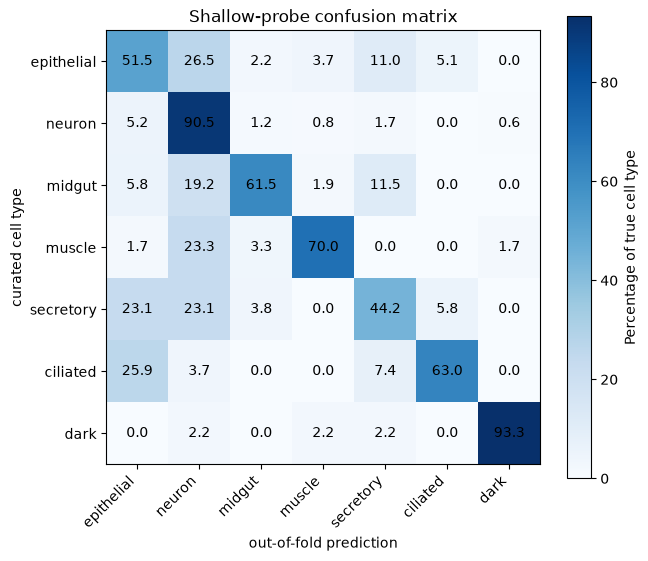

In [136]:
CLASSIFIER_MODEL = "mlp"  # change to "mlp" for a one-hidden-layer nonlinear probe
classifier_result = None
if embedding is not None:
    curated_labels_path = REPO_ROOT / "analysis" / "data" / "class_labels_mae_test.tsv"
    curated_labels = pd.read_csv(curated_labels_path, sep="\t")
    overlap = curated_labels[curated_labels["label_id"].isin(embedding.label_ids)]
    print("curated ID overlap:", len(overlap), "of", len(curated_labels))
    display(overlap["cell_type"].value_counts().rename("matched examples").to_frame())
    classifier_result = evaluate_embedding_classifier(
        destination, curated_labels_path,
        output_dir=config.run_dir / "analysis" / f"classifier_{CLASSIFIER_MODEL}",
        model=CLASSIFIER_MODEL, folds=5, seed=SEED, class_weight="balanced",
        hidden_dimensions=(64,), minimum_class_count=2, standardize=True, pca=False
    )
    print(f"accuracy: {classifier_result.mean_accuracy:.3f} ± {classifier_result.std_accuracy:.3f}")
    recall = pd.Series(
        classifier_result.per_class_recall, index=classifier_result.class_names, name="recall"
    )
    display(recall.to_frame())
    fig, axis = plt.subplots(figsize=(7, 6))
    image = axis.imshow(confusion_percentages_ex, cmap="Blues")
    axis.set_xticks(range(len(classifier_result.class_names)), classifier_result.class_names, rotation=45, ha="right")
    axis.set_yticks(range(len(classifier_result.class_names)), classifier_result.class_names)
    axis.set(xlabel="out-of-fold prediction", ylabel="curated cell type", title="Shallow-probe confusion matrix")
    for row in range(len(classifier_result.class_names)):
        for column in range(len(classifier_result.class_names)):
            axis.text(column, row, confusion_percentages_ex[row, column], ha="center", va="center")
    fig.colorbar(image, ax=axis, label="Percentage of true cell type")
    plt.show()
else:
    print("Classifier evaluation requires an encoded label-first embedding.")

In [81]:
curated_labels = analysis_frame[analysis_frame["cell_type"].notnull()][["label_id", "cell_type"]]

In [83]:
curated_labels.to_csv(REPO_ROOT / "analysis" / "data" / "class_labels_mae_test.tsv", sep="\t", index=False)

In [80]:
curated_labels

,label_id,cell_type
0,27641,ciliated
1,23159,ciliated
2,19347,ciliated
3,10963,ciliated
4,10559,ciliated
...,...,...
385,18991,muscle
386,26810,muscle
387,4603,muscle
388,10130,muscle


## 17 — Compare with the published fine-nucleus group, cautiously

The bundled published table is the most relevant historical group, but preprocessing, model,
checkpoint, and training cohort are not identical. We compare distance rankings only among exact
common IDs. For the two-epoch quick model this is an implementation/QC diagnostic, not a claim of
agreement or superiority. A defensible comparison needs full training, seeds/checkpoints,
held-out reconstruction, stability, and downstream tasks chosen before looking at results.

In [46]:
comparison = None
if embedding is not None:
    legacy_path = REPO_ROOT / "data_mobie" / "features_fine_ultr_nucl.tsv"
    legacy = pd.read_csv(legacy_path, sep="	")
    legacy["label_id"] = legacy["label_id"].round().astype("int64")
    common_ids = np.intersect1d(embedding.label_ids, legacy["label_id"])
    new_lookup = {int(label_id): row for row, label_id in enumerate(embedding.label_ids)}
    old_lookup = legacy.set_index("label_id")
    new_common = np.stack([embedding.features[new_lookup[int(label_id)]] for label_id in common_ids])
    old_common = old_lookup.loc[common_ids].to_numpy(dtype=float)
    if len(common_ids) >= 4:
        new_distances = pdist(StandardScaler().fit_transform(new_common), metric="cosine")
        old_distances = pdist(StandardScaler().fit_transform(old_common), metric="cosine")
        comparison = spearmanr(new_distances, old_distances)
        print("common label_ids:", len(common_ids), "| pairwise distances:", len(new_distances))
        print("descriptive distance-rank correlation:", comparison.statistic, "p:", comparison.pvalue)
    else:
        print("Too few common IDs for even a descriptive distance comparison.")
else:
    print("Checkpoint comparison requires embeddings.")

common label_ids: 10000 | pairwise distances: 49995000
descriptive distance-rank correlation: 0.34173985198239143 p: 0.0


## 18 — Export reusable results and provenance

The NumPy embedding and its JSON metadata were created by `encode_real_mae`. This cell adds a
MoBIE-compatible TSV whose first column is `label_id`, plus an analysis table and a concise
provenance record. It does not overwrite bundled published artifacts.

In [ ]:
if embedding is not None:
    export_dir = config.run_dir / "exports"
    export_dir.mkdir(parents=True, exist_ok=True)
    feature_columns = [f"nucleus_texture_mae_{index:03d}" for index in range(embedding.features.shape[1])]
    mobie_table = pd.DataFrame(embedding.features, columns=feature_columns)
    mobie_table.insert(0, "label_id", embedding.label_ids)
    mobie_path = export_dir / "nucleus_texture_mae.tsv"
    mobie_table.to_csv(mobie_path, sep="	", index=False)
    analysis_path = export_dir / "nucleus_texture_mae_analysis.tsv"
    analysis_frame.to_csv(analysis_path, sep="	", index=False)
    provenance_path = write_json_atomic(export_dir / "notebook_provenance.json", {
        "scope": "cell-associated nucleus-derived EM texture; not complete MorphoFeatures",
        "source_config": str(CONFIG_PATH),
        "resolved_config": str(resolved_path),
        "profile": PROFILE,
        "seed": SEED,
        "checkpoint": str(checkpoint_path),
        "embedding": str(embedding_path),
        "rows": int(len(embedding.label_ids)),
        "features": int(embedding.features.shape[1]),
        "comparison_is_exploratory": True,
    })
    print("MoBIE-compatible features:", mobie_path)
    print("joined analysis:", analysis_path)
    print("provenance:", provenance_path)
else:
    print("Export requires embeddings.")

## 19 — Applying this workflow to another dataset

Change data through YAML, not scattered cells:

1. Provide an N5 `uint8` patch dataset shaped `(n, z, y, x)` and an `int64` positions dataset
   shaped `(n, 4)` with rows `(label_id,z,y,x)`.
2. Provide a unique `ids` dataset and make it exactly equal to the position table's ID set.
3. State physical `resolution_zyx_um`, patch shape, coordinate grid resolution, biological unit,
   and mask semantics. Do not transpose axes implicitly.
4. If starting from volumes rather than patches, create them in a separate, versioned preparation
   step; keep raw, cell segmentation, nucleus segmentation, and cell→nucleus mapping provenance.
5. Visualize unmasked raw, segmentation/mask, stored patch, and normalized input. Quantify empty,
   malformed, duplicate, and extreme-occupancy samples.
6. Split at the biological parent level. Use animal/batch groups instead when they exist.
7. Start with `quick`, save the resolved config, then adapt `full` resources and inspect the exact
   SLURM script before explicit submission.
8. Judge training with held-out loss, reconstructions, embedding QC, seed/checkpoint stability,
   and ID-joined biological tasks—not job completion alone.

See `morphofeatures/howto_new_dataset.md` for a field-by-field mapping and
`docs/legacy_workspaces_inventory.md` for evidence, uncertainties, storage implications, and
questions that still need the original authors.